<a href="https://colab.research.google.com/github/nepslor/teaching/blob/main/CAS_BDML/L_06_TS_forecasting_example_refined.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [59]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb


df = pd.read_pickle('https://github.com/nepslor/teaching/raw/refs/heads/main/TimeSeriesForecasting/data/minichallenge/weather.pk')

In [60]:
df.tail(4)

,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
Date Time,,,,,,,,,,,,,,
2016-12-31 21:00:00,1001.063333,-2.653333,270.426667,-6.970000,72.016667,5.025000,3.616667,1.406667,2.248333,3.611667,1287.406667,0.573333,1.25,98.366667
2016-12-31 22:00:00,1000.511667,-3.553333,269.568333,-7.348333,74.916667,4.698333,3.515000,1.188333,2.188333,3.513333,1291.060000,0.816667,1.41,167.958333
2016-12-31 23:00:00,999.991667,-3.746667,269.413333,-8.161667,71.270000,4.628333,3.293333,1.331667,2.053333,3.293333,1291.415000,0.971667,1.65,223.600000
2017-01-01 00:00:00,999.820000,-4.820000,268.360000,-8.420000,75.700000,4.270000,3.230000,1.040000,2.010000,3.230000,1296.380000,1.230000,1.96,184.900000


In [61]:
df.columns = df.columns.str.replace(' ', '_')
df.head()

,p_(mbar),T_(degC),Tpot_(K),Tdew_(degC),rh_(%),VPmax_(mbar),VPact_(mbar),VPdef_(mbar),sh_(g/kg),H2OC_(mmol/mol),rho_(g/m**3),wv_(m/s),max._wv_(m/s),wd_(deg)
Date Time,,,,,,,,,,,,,,
2009-01-01 00:00:00,996.528000,-8.304000,265.118000,-9.120000,93.780000,3.260000,3.058000,0.202000,1.910000,3.068000,1309.196000,0.520000,1.002000,174.460000
2009-01-01 01:00:00,996.525000,-8.065000,265.361667,-8.861667,93.933333,3.323333,3.121667,0.201667,1.951667,3.133333,1307.981667,0.316667,0.711667,172.416667
2009-01-01 02:00:00,996.745000,-8.763333,264.645000,-9.610000,93.533333,3.145000,2.940000,0.201667,1.836667,2.950000,1311.816667,0.248333,0.606667,196.816667
2009-01-01 03:00:00,996.986667,-8.896667,264.491667,-9.786667,93.200000,3.111667,2.898333,0.210000,1.811667,2.906667,1312.813333,0.176667,0.606667,157.083333
2009-01-01 04:00:00,997.158333,-9.348333,264.026667,-10.345000,92.383333,3.001667,2.775000,0.231667,1.733333,2.780000,1315.355000,0.290000,0.670000,150.093333


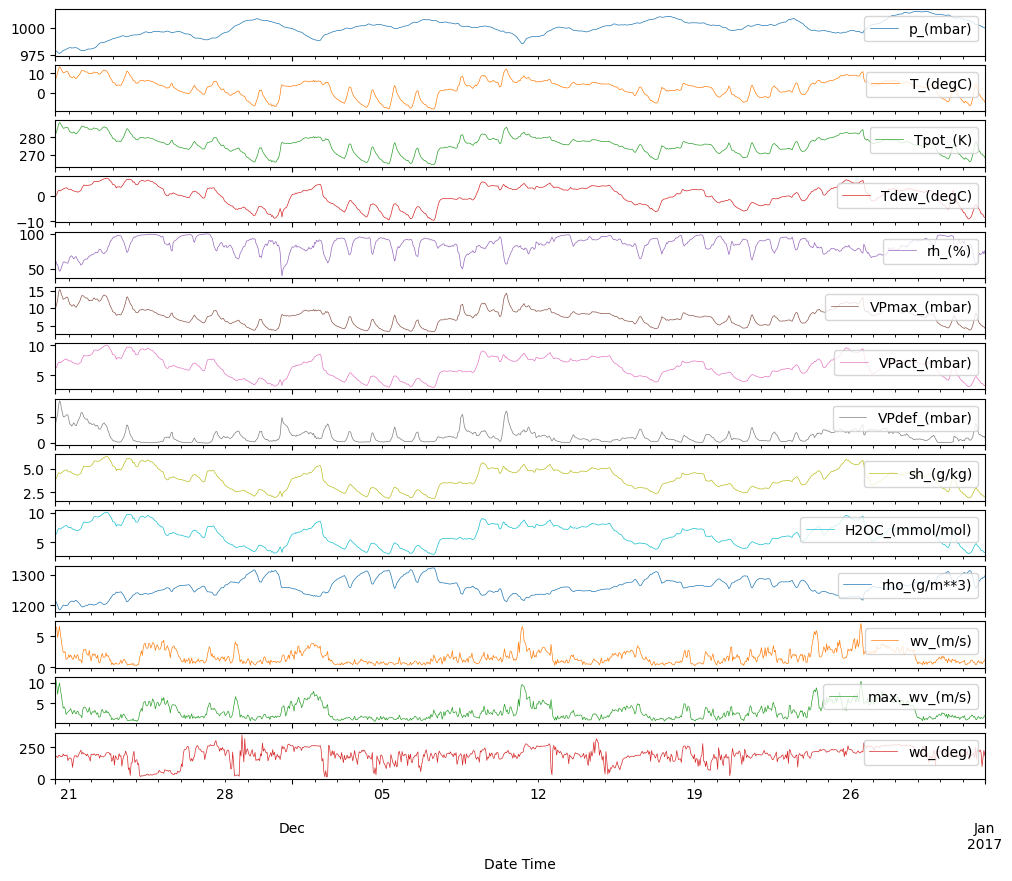

In [62]:
ax = df.tail(1000).plot(figsize=(12, 10), subplots=True, linewidth=0.5)
[a.legend(loc='upper right') for a in ax]
plt.show()

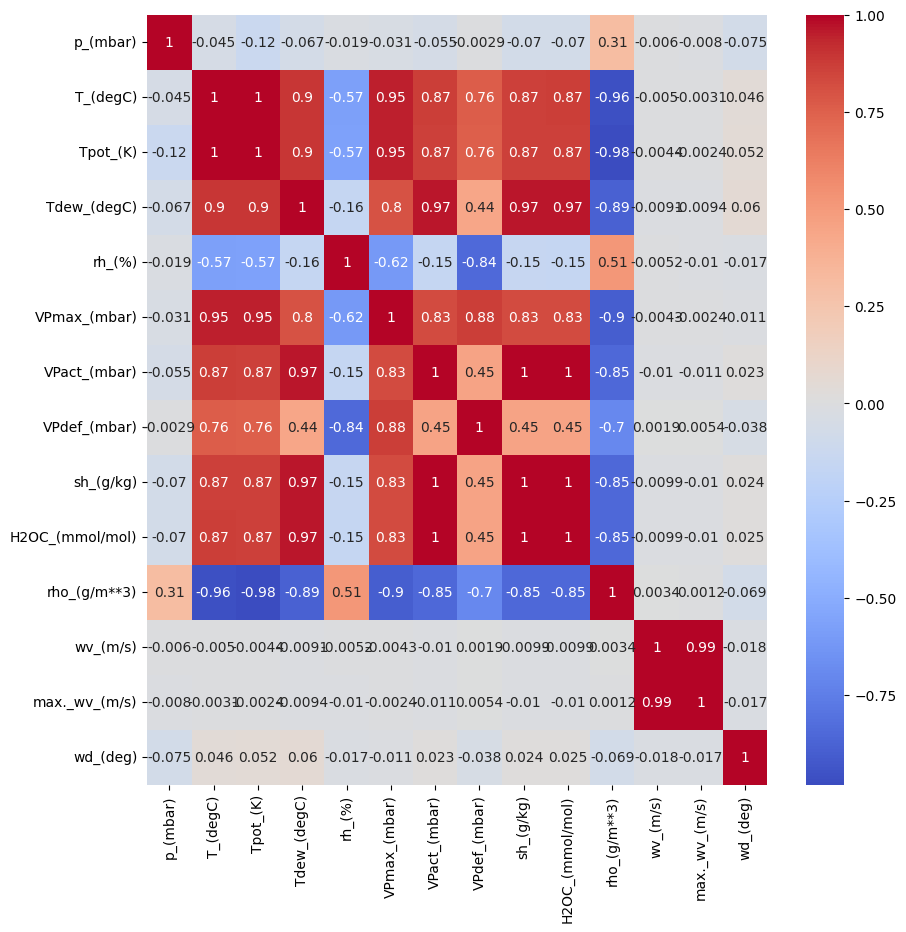

In [63]:
# correlation heatmap sb
fig, ax = plt.subplots(figsize=(10, 10))
sb.heatmap(df.corr(), annot=True, cmap='coolwarm', ax=ax)
plt.show()

In [64]:
target = 'T_(degC)'
df.corr()[target].abs().sort_values(ascending=False)

T_(degC)           1.000000
Tpot_(K)           0.996820
rho_(g/m**3)       0.963347
VPmax_(mbar)       0.951204
Tdew_(degC)        0.896856
VPact_(mbar)       0.869021
H2OC_(mmol/mol)    0.868516
sh_(g/kg)          0.868097
VPdef_(mbar)       0.762056
rh_(%)             0.572049
wd_(deg)           0.046040
p_(mbar)           0.045224
wv_(m/s)           0.004966
max._wv_(m/s)      0.003062
Name: T_(degC), dtype: float64

In [65]:
selected_vars = df.corr()[target].abs().sort_values(ascending=False).iloc[:-4].index
df = df[selected_vars]

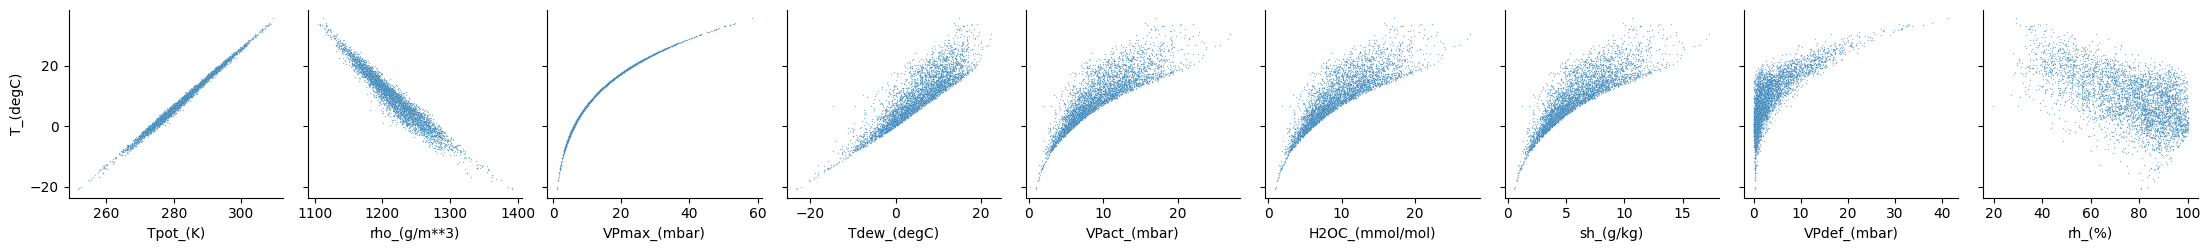

In [66]:
# pairplot seaborn
sb.pairplot(df.sample(4000), plot_kws={'alpha': 0.5, 's':1}, x_vars=selected_vars[1:], y_vars=[selected_vars[0]])
plt.show()

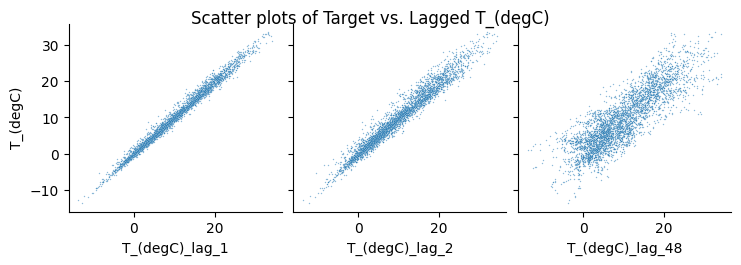

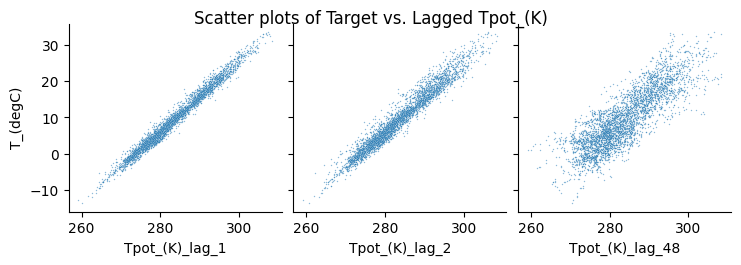

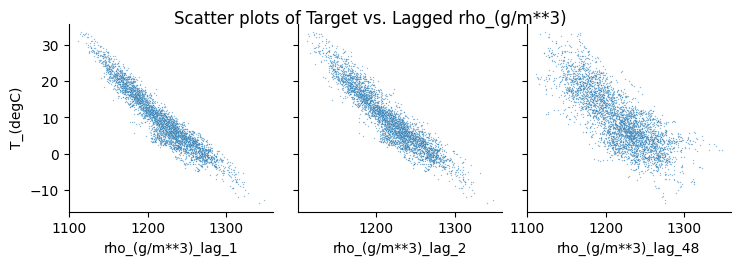

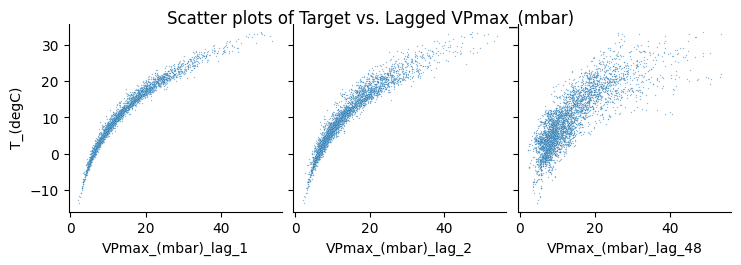

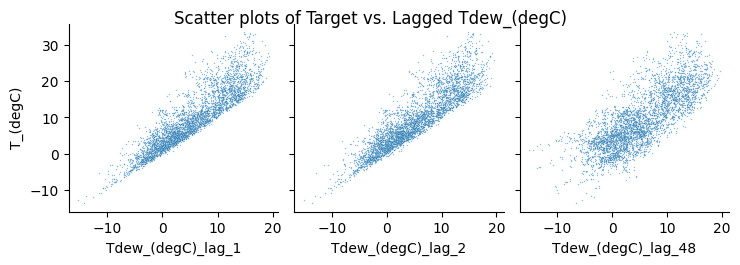

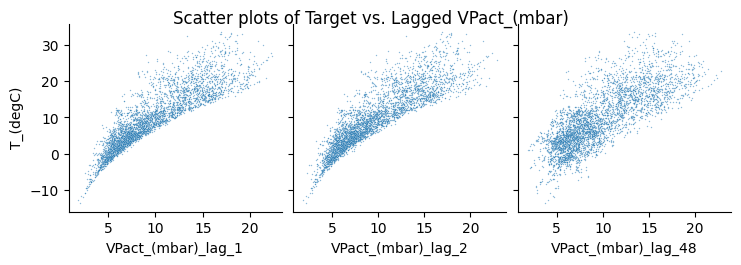

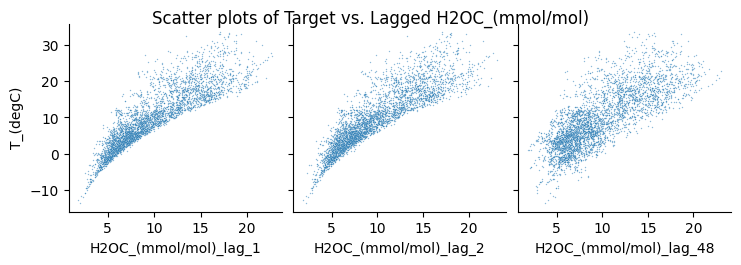

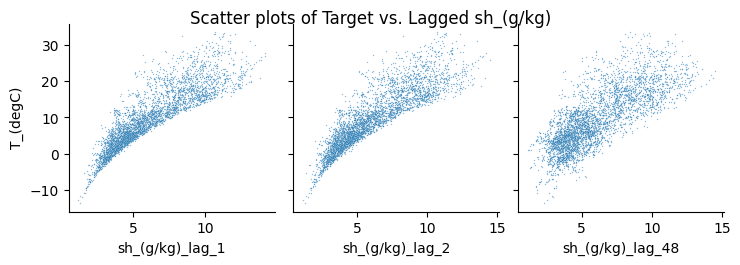

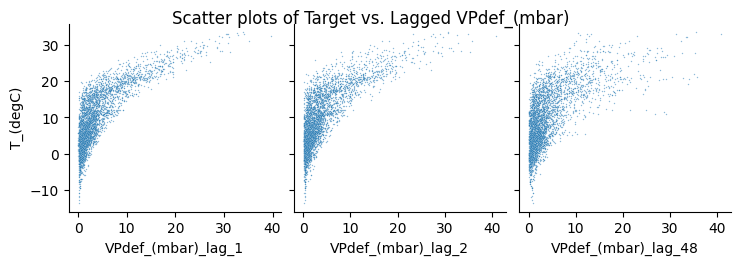

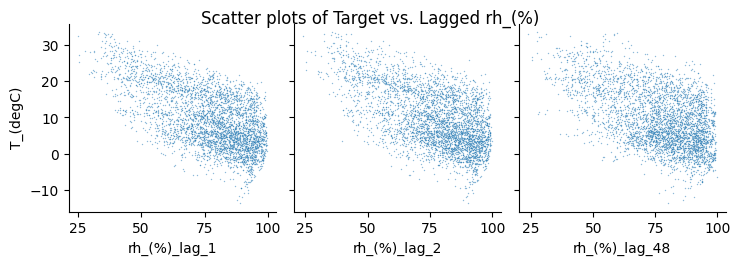

In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb

df_red = df.tail(10000)
lags_to_consider = np.hstack([np.arange(1, 3), 24*2])

for var_name in selected_vars:
    # Create a dictionary to collect lags and avoid fragmentation warning
    lag_data = {target: df_red[target]}

    for lag_val in lags_to_consider:
        col_name = f'{var_name}_lag_{lag_val}'
        lag_data[col_name] = df_red[var_name].shift(lag_val)

    # Construct the DataFrame once from the dictionary
    temp_df_for_plot = pd.DataFrame(lag_data, index=df_red.index).dropna()

    if not temp_df_for_plot.empty:
        lag_cols = [c for c in temp_df_for_plot.columns if c != target]
        # Sample the data to keep the plot generation efficient
        sample_size = min(4000, len(temp_df_for_plot))
        g = sb.pairplot(temp_df_for_plot.sample(sample_size, random_state=42),
                        plot_kws={'alpha': 0.5, 's': 1},
                        x_vars=lag_cols,
                        y_vars=[target])
        g.fig.suptitle(f'Scatter plots of Target vs. Lagged {var_name}', y=1.02)
        plt.show()
    else:
        print(f'Skipping {var_name} due to empty data.')

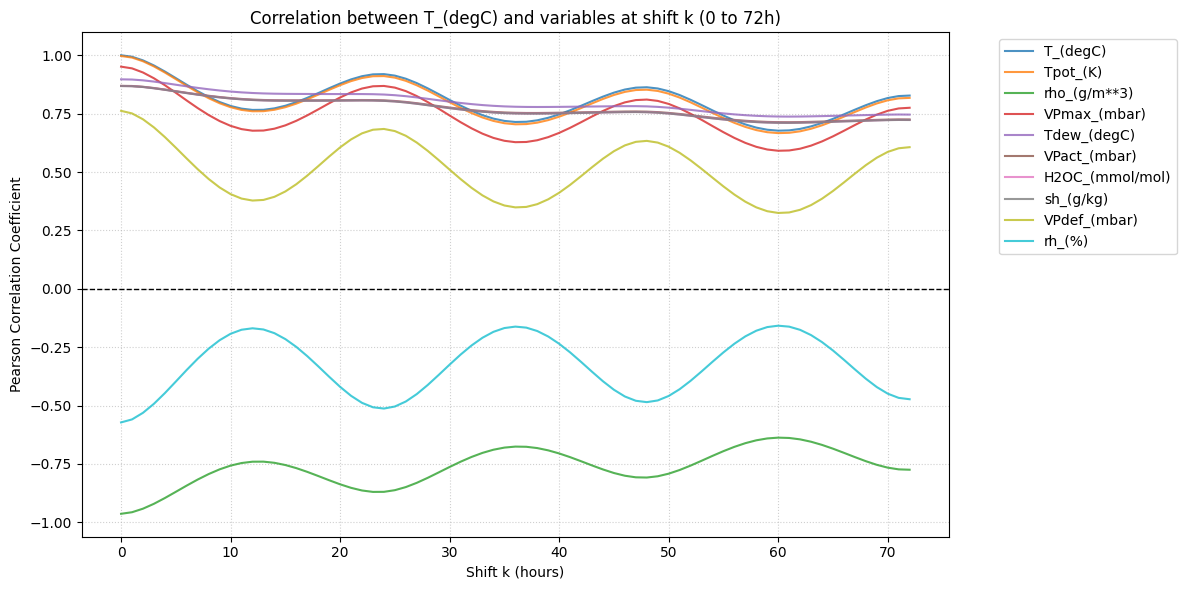

In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Define the shift range: 0 to 72 hours (24*3)
lags = np.arange(0, 73)
corr_matrix = pd.DataFrame(index=lags, columns=selected_vars)

for var in selected_vars:
    for k in lags:
        # Correlation between current target and variable shifted by k steps
        corr_matrix.loc[k, var] = df[target].corr(df[var].shift(k))

corr_matrix = corr_matrix.astype(float)

# Plotting as line plot
plt.figure(figsize=(12, 6))
for var in selected_vars:
    plt.plot(corr_matrix.index, corr_matrix[var], label=var, alpha=0.8)

plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.title(f'Correlation between {target} and variables at shift k (0 to 72h)')
plt.xlabel('Shift k (hours)')
plt.ylabel('Pearson Correlation Coefficient')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

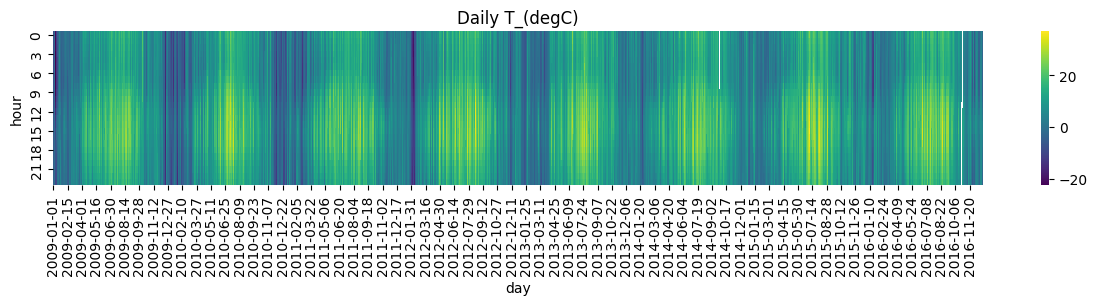

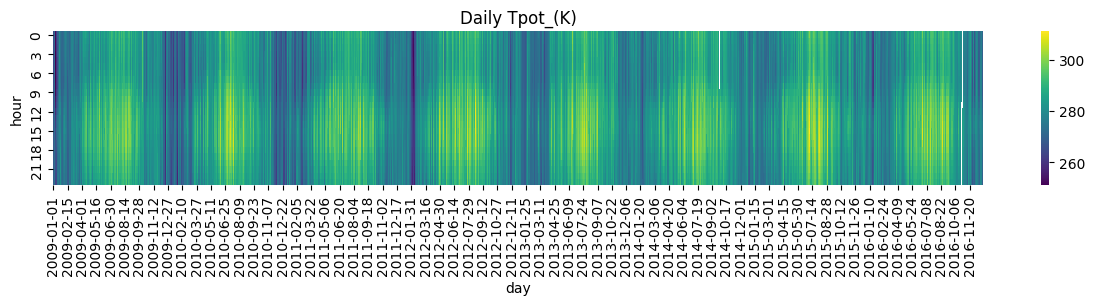

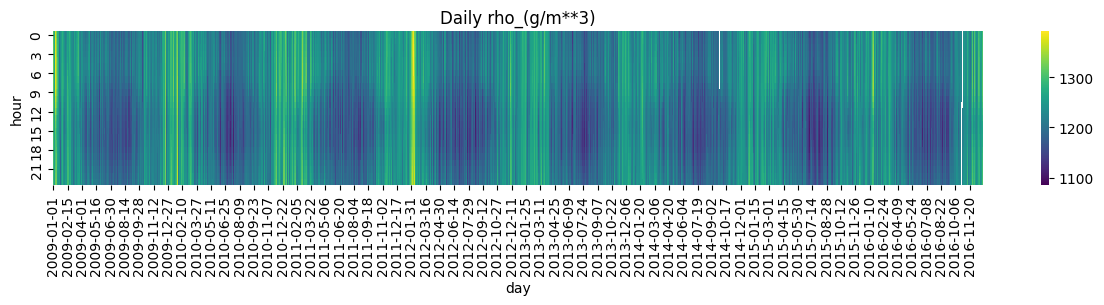

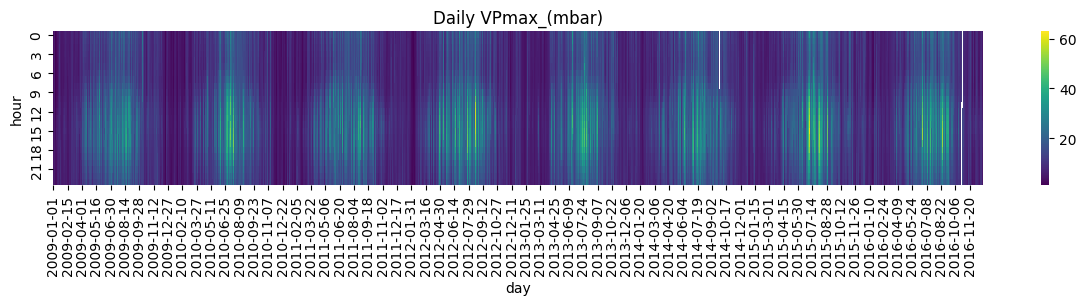

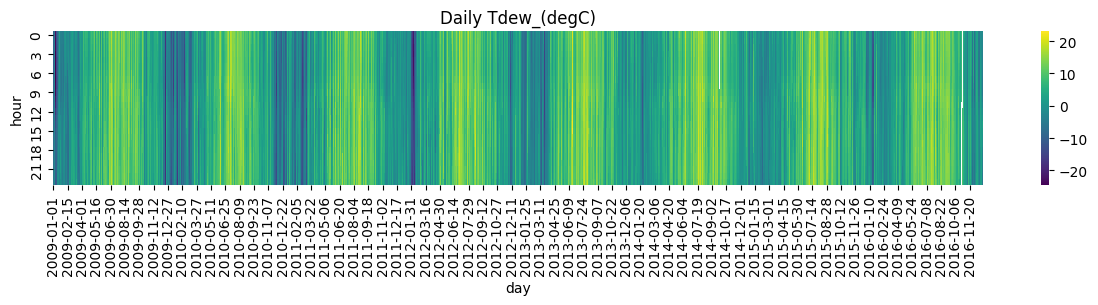

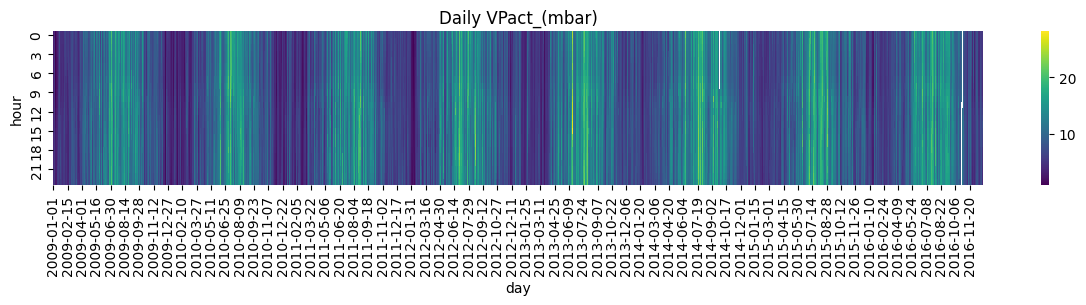

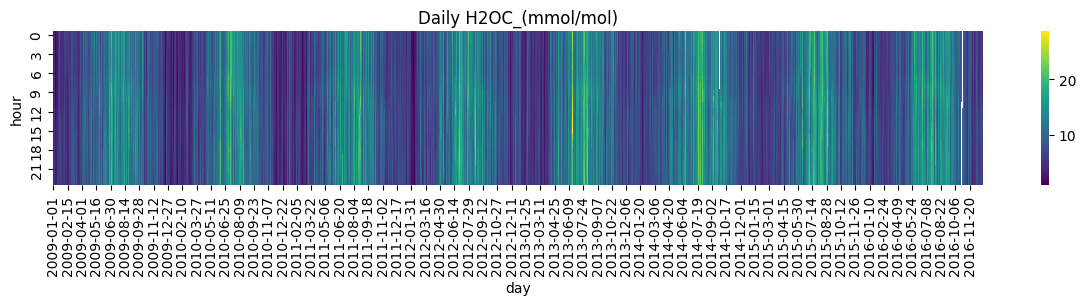

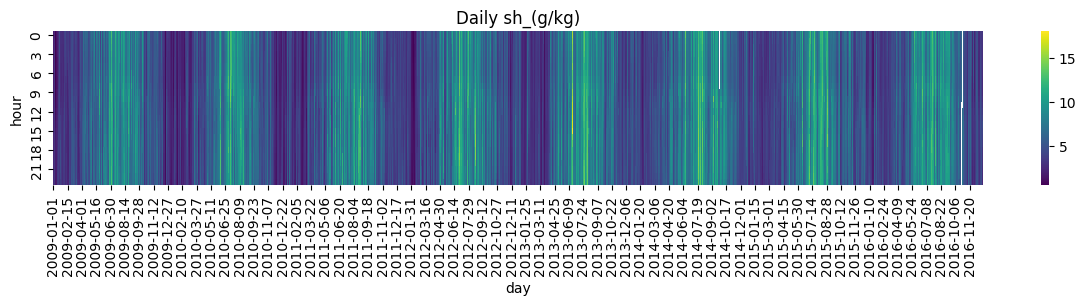

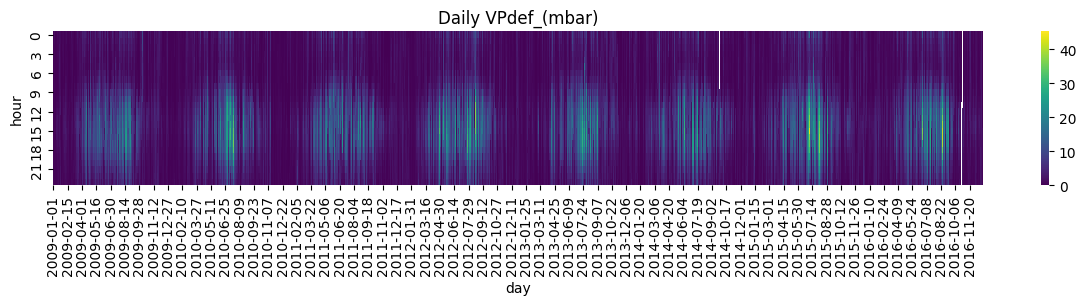

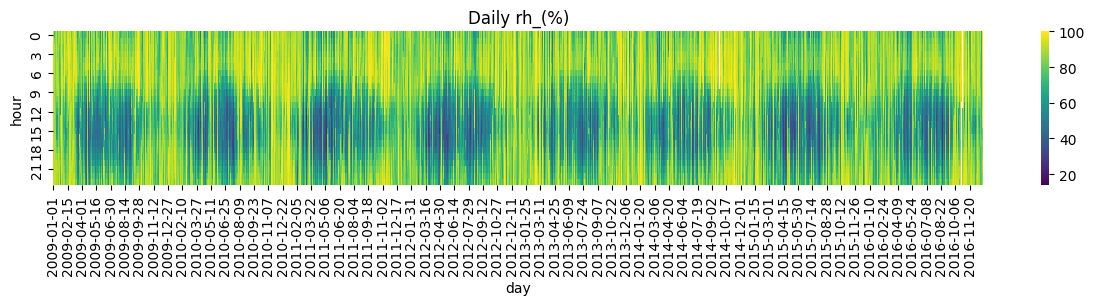

In [69]:
for v in selected_vars:
  daily_v = df.assign(                            # assign method temporaly adds new features to a dataframe
      day=df.index.date,
      hour=df.index.hour
  ).pivot(index='hour', columns='day', values=v)  # pivot create a matrix from "index" and "columns"

  # plot heatmap
  fig, ax = plt.subplots(figsize=(15, 2))
  sb.heatmap(daily_v, cmap='viridis', ax=ax)
  ax.set_title('Daily {}'.format(v))


In [70]:
df = df.ffill().bfill()

<Axes: xlabel='Date Time'>

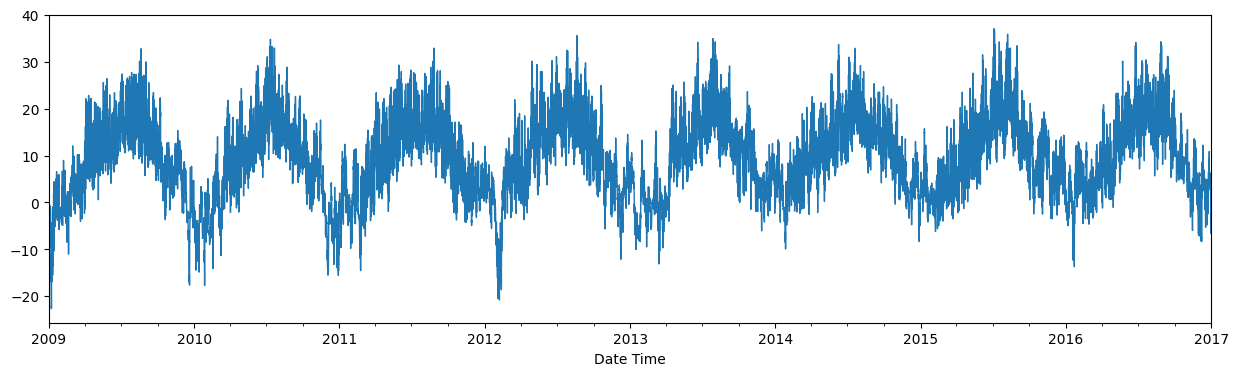

In [71]:
df[target].plot(linewidth=1, figsize=(15, 4))

<Axes: xlabel='Date Time'>

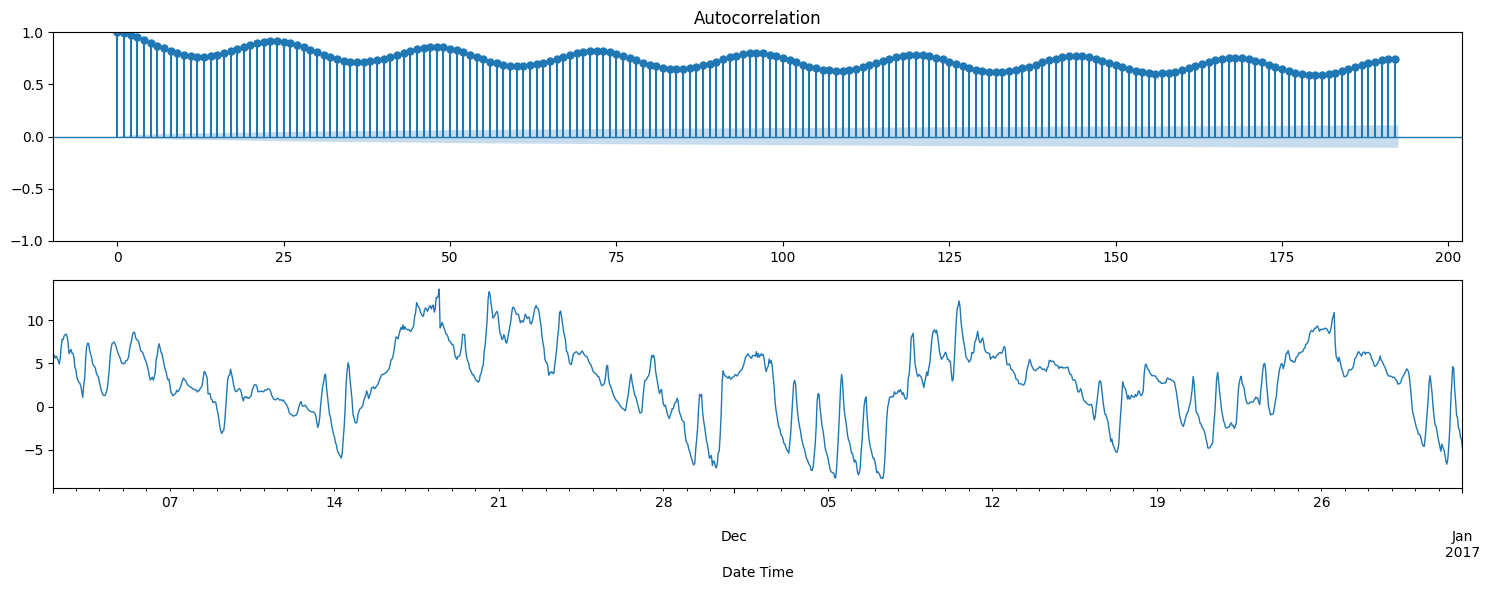

In [72]:
from statsmodels.graphics.tsaplots import plot_acf
fig, ax = plt.subplots(2, 1, figsize=(15, 6), layout='tight')
plot_acf(df[target], lags=24*8, ax=ax[0], linewidth=1);
df[target].tail(24*60).plot(linewidth=1, ax=ax[1])



In [73]:

from statsmodels.tsa.stattools import adfuller

result = adfuller(df[target].tail(24*30), autolag='AIC')
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])


result = adfuller(df[target].tail(24*30).diff().dropna(), autolag='AIC')
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])


ADF Statistic: -1.118432
p-value: 0.707666
ADF Statistic: -8.205850
p-value: 0.000000


The time series is not stationary but it is when defferentiated

In [74]:
from lightgbm import LGBMRegressor
from sklearn.neighbors import KNeighborsRegressor
from statsforecast.models import AutoETS
from tqdm import tqdm

import numpy as np



In [75]:
df_red = df.tail(10000)

tr_ratio = 0.7
n_tr = int(len(df_red) * tr_ratio)

def add_lags(df, vars, lags):
    # Create a dictionary to hold the new columns
    lag_dict = {col: df[col] for col in df.columns}

    for v in vars:
        for l in lags:
            lag_dict['{}_lag_{}'.format(v, l)] = df[v].shift(l)

    # Create the final DataFrame from the dictionary all at once
    return pd.DataFrame(lag_dict).dropna()

# add target transform
y = add_lags(df_red[[target]], [target], -np.arange(1, 25)).iloc[:, 1:]
X = add_lags(df_red, selected_vars[1:], np.hstack([np.arange(1, 25), 24*2, 24*3, 24*4]))
df_postprocess = pd.concat({'X':X, 'y':y}, axis=1).dropna()

X_tr, y_tr = df_postprocess['X'].iloc[:n_tr], df_postprocess['y'].iloc[:n_tr]
X_te, y_te = df_postprocess['X'].iloc[n_tr:], df_postprocess['y'].iloc[n_tr:]

lgb_models = [LGBMRegressor(force_col_wise=True,verbose=0).fit(X_tr, y_tr[c].values) for c in tqdm(y.columns, desc='fitting LGBM')]
y_hat_lgb = pd.DataFrame({f'{target}_lag_{-l}': m.predict(X_te) for l, m in enumerate(lgb_models, 1)}, index=y_te.index)
y_hat_knn = pd.DataFrame(KNeighborsRegressor().fit(X_tr, y_tr.values).predict(X_te), index=y_te.index)

horizon = y_tr.shape[1]

def rolling_forward_predictions(fitted_model, y_train_hist, y_stream, horizon):
    y_hat = []
    y_train_hist = np.asarray(y_train_hist, dtype=float)
    y_stream = np.asarray(y_stream, dtype=float)

    for i in tqdm(range(len(y_stream)), desc='AutoETS rolling'):
        y_past = np.hstack([y_train_hist, y_stream[:i]])
        preds = fitted_model.forward(y_past, h=horizon)
        y_hat.append(np.asarray(preds['mean'], dtype=float))

    return np.vstack(y_hat)

y_train_hist_ets = df_red.loc[:X_te.index[0], target].iloc[:-1].values
y_stream_ets = X_te[target].values

fitted_model = AutoETS(season_length=24, model='ZZA')
fitted_model.fit(y_train_hist_ets)

y_hat_ets = pd.DataFrame(
    rolling_forward_predictions(fitted_model, y_train_hist_ets, y_stream_ets, horizon),
    index=y_te.index,
    columns=y_te.columns,
)

AutoETS rolling: 100%|██████████| 2880/2880 [00:00<00:00, 5155.43it/s]


In [76]:
import plotly.graph_objects as go

def _slice_forecast_array(x, start, stop):
    return np.asarray(x.iloc[start:stop] if hasattr(x, 'iloc') else x[start:stop])

def animate_forecasts(y_te, forecasts, n_rows=24*30, skip=24*7, width=900, height=450):
    available_rows = [len(y_te)] + [len(y_hat) for y_hat in forecasts.values()]
    n_rows = min(n_rows, min(available_rows) - skip)
    stop = skip + n_rows

    y_true = _slice_forecast_array(y_te, skip, stop)
    y_preds = {name: _slice_forecast_array(y_hat, skip, stop) for name, y_hat in forecasts.items()}

    if y_true.ndim != 2 or any(y_pred.ndim != 2 for y_pred in y_preds.values()):
        raise ValueError('Expected y_te and all forecasts to be 2D arrays or DataFrames.')

    horizon = y_true.shape[1]
    t = np.arange(horizon)

    fig = go.Figure(layout=dict(width=width, height=height))
    fig.add_trace(go.Scatter(x=t, y=y_true[0], mode='lines', line=dict(width=2), name='observed'))

    for name, y_pred in y_preds.items():
        fig.add_trace(go.Scatter(x=t, y=y_pred[0], mode='lines', line=dict(width=2), name=name))

    frames = []
    for i in range(n_rows):
        frame_data = [go.Scatter(y=y_true[i])]
        frame_data.extend(go.Scatter(y=y_pred[i]) for y_pred in y_preds.values())
        frames.append(go.Frame(data=frame_data, name=f'frame{i}'))

    fig.frames = frames

    y_min = min(np.min(y_true), *(np.min(y_pred) for y_pred in y_preds.values())) - 1
    y_max = max(np.max(y_true), *(np.max(y_pred) for y_pred in y_preds.values())) + 1

    fig.update_layout(
        title='Point Forecast Animation',
        margin={'l': 30, 'r': 20, 't': 35, 'b': 30},
        updatemenus=[{
            'type': 'buttons',
            'buttons': [{
                'label': 'Play',
                'method': 'animate',
                'args': [None, {
                    'frame': {'duration': 50, 'redraw': True},
                    'fromcurrent': True,
                    'transition': {'duration': 0},
                }],
            }],
        }],
    )
    fig.update_yaxes(range=[y_min, y_max], automargin=True)
    fig.update_xaxes(automargin=True)

    return fig

animate_forecasts(y_te, {'lgb': y_hat_lgb, 'knn': y_hat_knn, 'autoets': y_hat_ets})

In [77]:
df_red_diff = df_red.copy()
df_red_diff[[target]] = df_red_diff[[target]].diff().dropna()

# add target transform
y = add_lags(df_red_diff[[target]], [target], -np.arange(1, 25)).iloc[:, 1:]
X = add_lags(df_red_diff.drop(columns=[target]), selected_vars[1:], np.hstack([np.arange(1, 25), 24*2]))
df_postprocess = pd.concat({'X':X, 'y':y}, axis=1).dropna()

X_tr_diff, y_tr_diff = df_postprocess['X'].iloc[:n_tr], df_postprocess['y'].iloc[:n_tr]
X_te_diff, y_te_diff = df_postprocess['X'].iloc[n_tr:], df_postprocess['y'].iloc[n_tr:]


lgb_models = [LGBMRegressor(force_col_wise=True,verbose=0).fit(X_tr_diff, y_tr_diff[c].values) for c in tqdm(y.columns, desc='fitting LGBM diff')]
y_hat_lgb_diff = pd.DataFrame({f'{target}_lag_{-l}': m.predict(X_te_diff) for l, m in enumerate(lgb_models, 1)}, index=y_te_diff.index)
y_hat_knn_diff = pd.DataFrame(KNeighborsRegressor().fit(X_tr_diff, y_tr_diff.values).predict(X_te_diff), index=y_te_diff.index)

y_train_hist_ets_diff = df_red_diff.loc[:X_te_diff.index[0], target].dropna().iloc[:-1].values
y_stream_ets_diff = df_red_diff.loc[y_te_diff.index, target].values

fitted_model_diff = AutoETS(season_length=24, model='ZZA')
fitted_model_diff.fit(y_train_hist_ets_diff)

y_hat_ets_diff = pd.DataFrame(
    rolling_forward_predictions(fitted_model_diff, y_train_hist_ets_diff, y_stream_ets_diff, horizon),
    index=y_te_diff.index,
    columns=y_te_diff.columns,
)


AutoETS rolling: 100%|██████████| 2928/2928 [00:00<00:00, 5379.26it/s]


In [78]:
common_idx = y_te.index.intersection(y_hat_lgb_diff.index).intersection(y_hat_knn_diff.index).intersection(y_hat_ets_diff.index)

trend_level = df_red.loc[common_idx, target].to_numpy().reshape(-1, 1)
y_hat_lgb_rec = pd.DataFrame(
    trend_level + y_hat_lgb_diff.loc[common_idx].cumsum(axis=1).to_numpy(),
    index=common_idx,
    columns=y_hat_lgb_diff.columns,
)
y_hat_knn_rec = pd.DataFrame(
    trend_level + y_hat_knn_diff.loc[common_idx].cumsum(axis=1).to_numpy(),
    index=common_idx,
    columns=y_hat_knn_diff.columns,
)
y_hat_ets_rec = pd.DataFrame(
    trend_level + y_hat_ets_diff.loc[common_idx].cumsum(axis=1).to_numpy(),
    index=common_idx,
    columns=y_hat_ets_diff.columns,
)

y_te_rec = y_te.loc[common_idx]
animate_forecasts(y_te_rec, {'lgb diff': y_hat_lgb_rec, 'knn diff': y_hat_knn_rec, 'autoets diff': y_hat_ets_rec})

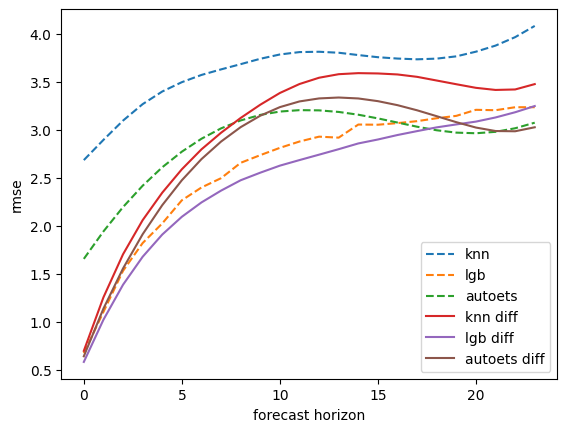

In [79]:
y_te_rec = y_te.loc[y_hat_lgb_rec.index]

plt.plot(np.mean((y_hat_knn-y_te.values)**2, axis=0).values**0.5, linestyle='--', label='knn')
plt.plot(np.mean((y_hat_lgb-y_te.values)**2, axis=0).values**0.5, linestyle='--', label='lgb')
plt.plot(np.mean((y_hat_ets-y_te.values)**2, axis=0).values**0.5, linestyle='--', label='autoets')

plt.plot(np.mean((y_hat_knn_rec-y_te_rec.values).values**2, axis=0)**0.5, label='knn diff')
plt.plot(np.mean((y_hat_lgb_rec-y_te_rec.values).values**2, axis=0)**0.5, label='lgb diff')
plt.plot(np.mean((y_hat_ets_rec-y_te_rec.values).values**2, axis=0)**0.5, label='autoets diff')

plt.xlabel('forecast horizon')
plt.ylabel('rmse')
plt.legend()



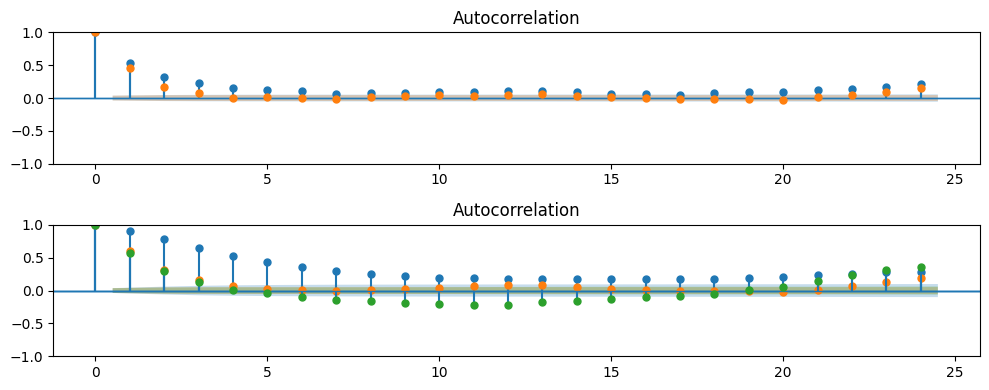

In [80]:
# plot ACF of residuals
y_te_rec = y_te.loc[y_hat_lgb_rec.index]

fig, ax = plt.subplots(2, 1, figsize=(10, 4), layout='tight')
plot_acf((y_hat_lgb-y_te.values).values[:, 0], lags=24, ax=ax[0], linewidth=1);
plot_acf((y_hat_knn-y_te.values).values[:, 0], lags=24, ax=ax[1], linewidth=1);


plot_acf((y_hat_lgb_rec-y_te_rec.values).values[:, 0], lags=24, ax=ax[0], linewidth=1);
plot_acf((y_hat_knn_rec-y_te_rec.values).values[:, 0], lags=24, ax=ax[1], linewidth=1);
plot_acf((y_hat_ets_rec-y_te_rec.values).values[:, 0], lags=24, ax=ax[1], linewidth=1);


